# ============================================
# Project : Student Performance Prediction
# File    : 01_eda.ipynb
# Author  : Janusha Weerasinghe
# ============================================


# Import Libraries

In [12]:
import pandas as pd
import numpy as np
from pathlib import Path

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

# Project Root and file paths 

In [32]:
# Project Root
PROJECT_ROOT = Path.cwd().parent

# Data Path
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student_performance.csv"
REPORT_DIR = PROJECT_ROOT / "reports"
FIGURE_DIR = REPORT_DIR / "figures"

print("Current Directory:", Path.cwd())
print("Project Root:", PROJECT_ROOT)
print("Dataset Exists:", DATA_PATH.exists())
print("Dataset Path:", DATA_PATH)

# or whe can use "df = pd.read_csv("../data/raw/student_performance.csv")"

Current Directory: d:\AI-Projects\student-performance-prediction\notebooks
Project Root: d:\AI-Projects\student-performance-prediction
Dataset Exists: True
Dataset Path: d:\AI-Projects\student-performance-prediction\data\raw\student_performance.csv


# Load Dataset

In [33]:
PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data" / "raw" / "student_performance.csv"

df = pd.read_csv(DATA_PATH)

df.head()

,Hours_Studied,Attendance,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Sleep_Hours,Previous_Scores,Motivation_Level,Internet_Access,Tutoring_Sessions,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Physical_Activity,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender,Exam_Score
0,23,84,Low,High,No,7,73,Low,Yes,0,Low,Medium,Public,Positive,3,No,High School,Near,Male,67
1,19,64,Low,Medium,No,8,59,Low,Yes,2,Medium,Medium,Public,Negative,4,No,College,Moderate,Female,61
2,24,98,Medium,Medium,Yes,7,91,Medium,Yes,2,Medium,Medium,Public,Neutral,4,No,Postgraduate,Near,Male,74
3,29,89,Low,Medium,Yes,8,98,Medium,Yes,1,Medium,Medium,Public,Negative,4,No,High School,Moderate,Male,71
4,19,92,Medium,Medium,Yes,6,65,Medium,Yes,3,Medium,High,Public,Neutral,4,No,College,Near,Female,70


# Dataset Shape

In [34]:
df.shape

(6607, 20)

# Dataset Information

In [35]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6607 entries, 0 to 6606
Data columns (total 20 columns):
 #   Column                      Non-Null Count  Dtype
---  ------                      --------------  -----
 0   Hours_Studied               6607 non-null   int64
 1   Attendance                  6607 non-null   int64
 2   Parental_Involvement        6607 non-null   str  
 3   Access_to_Resources         6607 non-null   str  
 4   Extracurricular_Activities  6607 non-null   str  
 5   Sleep_Hours                 6607 non-null   int64
 6   Previous_Scores             6607 non-null   int64
 7   Motivation_Level            6607 non-null   str  
 8   Internet_Access             6607 non-null   str  
 9   Tutoring_Sessions           6607 non-null   int64
 10  Family_Income               6607 non-null   str  
 11  Teacher_Quality             6529 non-null   str  
 12  School_Type                 6607 non-null   str  
 13  Peer_Influence              6607 non-null   str  
 14  Physical_Activity  

# Descriptive Statistics

In [36]:
df.describe()

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
count,6607.000000,6607.000000,6607.00000,6607.000000,6607.000000,6607.000000,6607.000000
mean,19.975329,79.977448,7.02906,75.070531,1.493719,2.967610,67.235659
std,5.990594,11.547475,1.46812,14.399784,1.230570,1.031231,3.890456
min,1.000000,60.000000,4.00000,50.000000,0.000000,0.000000,55.000000
25%,16.000000,70.000000,6.00000,63.000000,1.000000,2.000000,65.000000
50%,20.000000,80.000000,7.00000,75.000000,1.000000,3.000000,67.000000
75%,24.000000,90.000000,8.00000,88.000000,2.000000,4.000000,69.000000
max,44.000000,100.000000,10.00000,100.000000,8.000000,6.000000,101.000000


In [37]:
df.describe(include="object")

,Parental_Involvement,Access_to_Resources,Extracurricular_Activities,Motivation_Level,Internet_Access,Family_Income,Teacher_Quality,School_Type,Peer_Influence,Learning_Disabilities,Parental_Education_Level,Distance_from_Home,Gender
count,6607,6607,6607,6607,6607,6607,6529,6607,6607,6607,6517,6540,6607
unique,3,3,2,3,2,3,3,2,3,2,3,3,2
top,Medium,Medium,Yes,Medium,Yes,Low,Medium,Public,Positive,No,High School,Near,Male
freq,3362,3319,3938,3351,6108,2672,3925,4598,2638,5912,3223,3884,3814


# Missing Values

In [38]:
df.isnull().sum()

Hours_Studied                  0
Attendance                     0
Parental_Involvement           0
Access_to_Resources            0
Extracurricular_Activities     0
Sleep_Hours                    0
Previous_Scores                0
Motivation_Level               0
Internet_Access                0
Tutoring_Sessions              0
Family_Income                  0
Teacher_Quality               78
School_Type                    0
Peer_Influence                 0
Physical_Activity              0
Learning_Disabilities          0
Parental_Education_Level      90
Distance_from_Home            67
Gender                         0
Exam_Score                     0
dtype: int64

In [39]:
# Presenatage

(df.isnull().sum()/len(df))*100

Hours_Studied                 0.000000
Attendance                    0.000000
Parental_Involvement          0.000000
Access_to_Resources           0.000000
Extracurricular_Activities    0.000000
Sleep_Hours                   0.000000
Previous_Scores               0.000000
Motivation_Level              0.000000
Internet_Access               0.000000
Tutoring_Sessions             0.000000
Family_Income                 0.000000
Teacher_Quality               1.180566
School_Type                   0.000000
Peer_Influence                0.000000
Physical_Activity             0.000000
Learning_Disabilities         0.000000
Parental_Education_Level      1.362192
Distance_from_Home            1.014076
Gender                        0.000000
Exam_Score                    0.000000
dtype: float64

<Axes: >

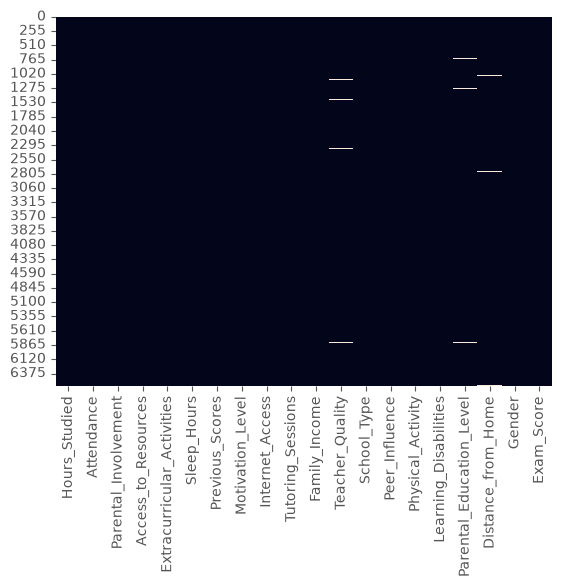

In [40]:
# Visualization

sns.heatmap(df.isnull(),cbar=False)

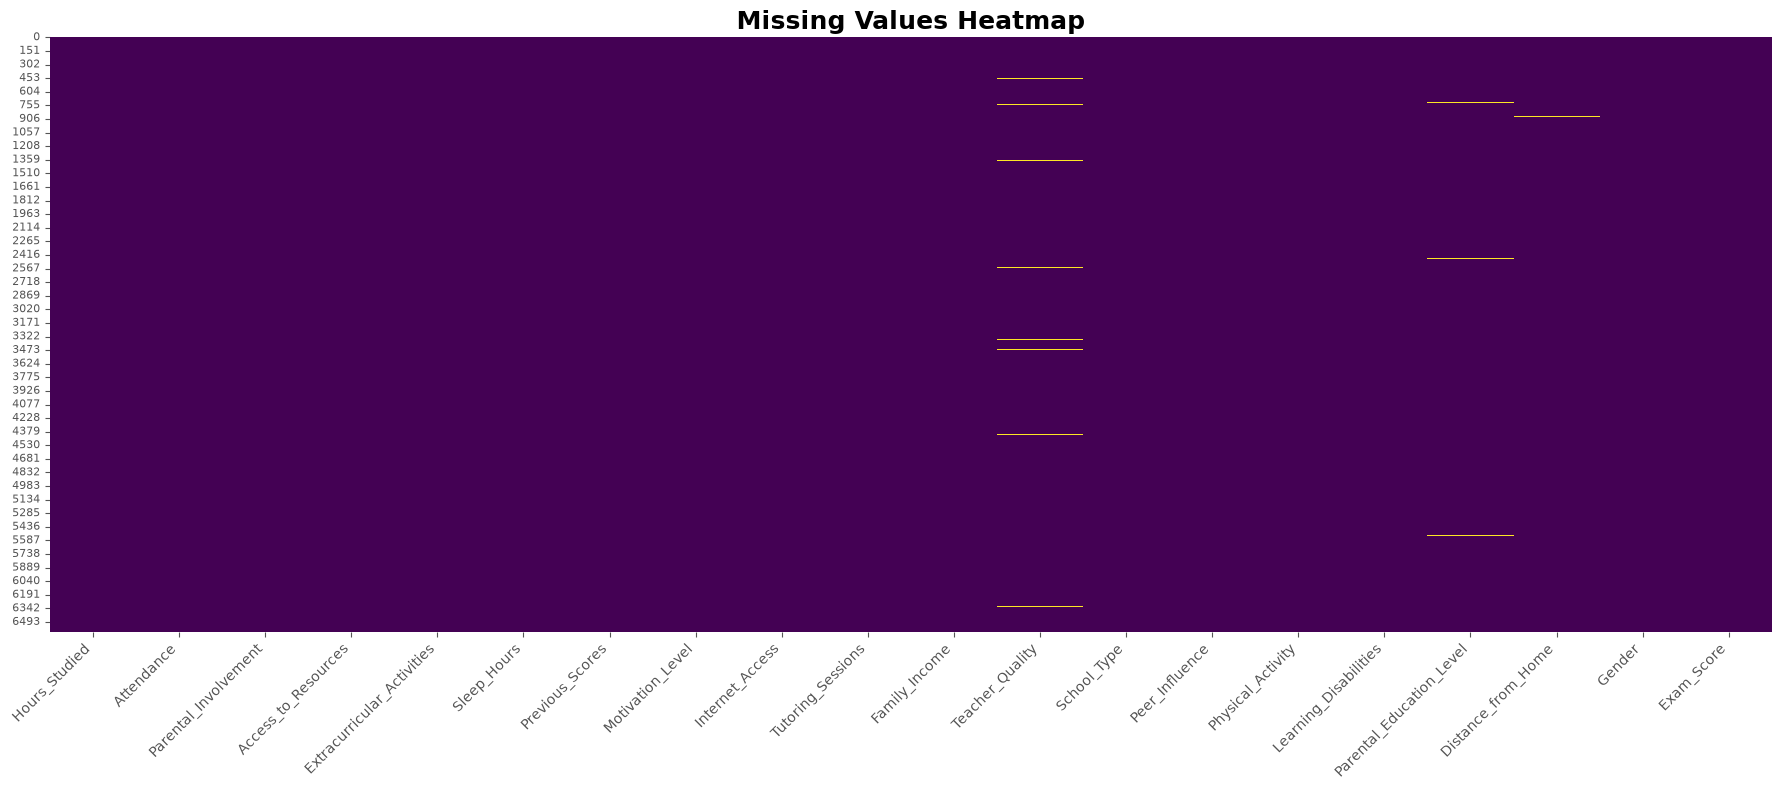

In [43]:
# Save

plt.figure(figsize=(18,8))

sns.heatmap(
    df.isnull(),
    cbar=False,
    cmap="viridis"
)

plt.title(
    "Missing Values Heatmap",
    fontsize=18,
    fontweight="bold"
)

plt.xticks(rotation=45, ha="right", fontsize=10)
plt.yticks(fontsize=8)

plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "missing_values.png",
    dpi=300,
    bbox_inches="tight" #Don't crop my labels.
)

plt.show()

# Duplicate Rows

In [44]:
df.duplicated().sum()

np.int64(0)

# Target Variable Analysis

In [46]:
# Target Variable = Exam_Score

# Target variable summary
df["Exam_Score"].describe()

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64

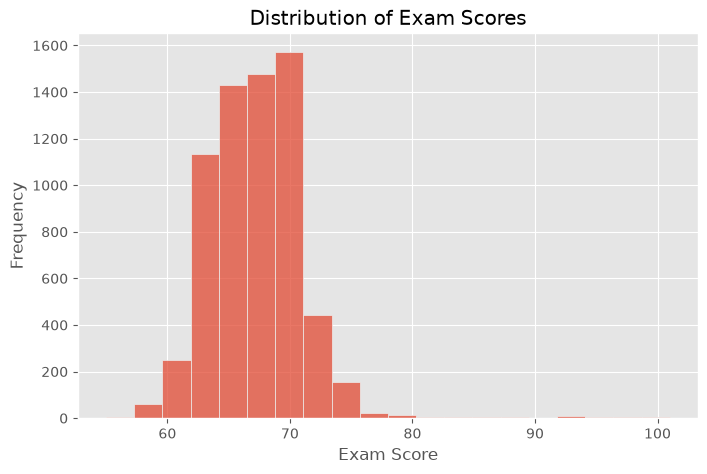

In [47]:
# Histogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Exam_Score",
    bins=20,
    kde=False
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.show()

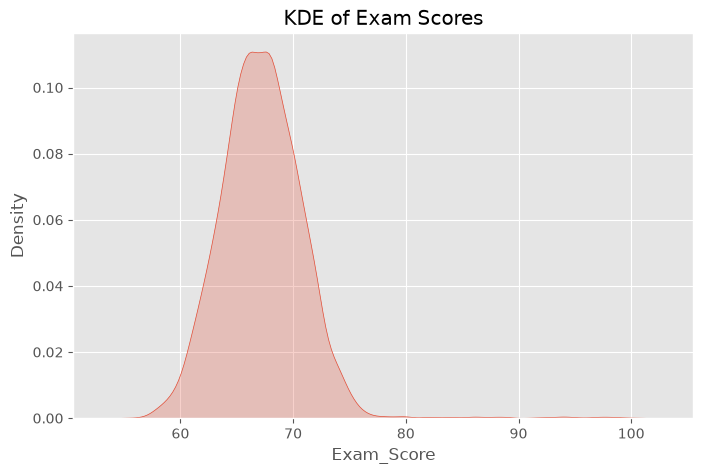

In [48]:
# KDE Plot
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="Exam_Score",
    fill=True
)

plt.title("KDE of Exam Scores")

plt.show()

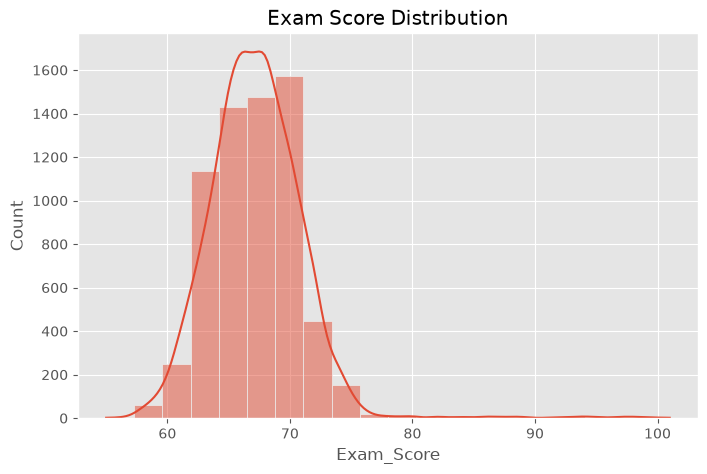

In [49]:
# Histogram + KDE (Recommended)

# This combines both views in one chart.

plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Exam_Score",
    bins=20,
    kde=True
)

plt.title("Exam Score Distribution")

plt.show()

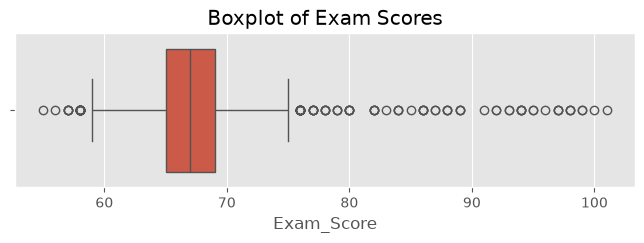

In [50]:
# Boxplot
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["Exam_Score"]
)

plt.title("Boxplot of Exam Scores")

plt.show()

In [51]:
# Skewness
df["Exam_Score"].skew()

np.float64(1.6448082853982677)

In [52]:
# Kurtosis (Optional but Professional)
df["Exam_Score"].kurtosis()

np.float64(10.575422734795485)

count    6607.000000
mean       67.235659
std         3.890456
min        55.000000
25%        65.000000
50%        67.000000
75%        69.000000
max       101.000000
Name: Exam_Score, dtype: float64


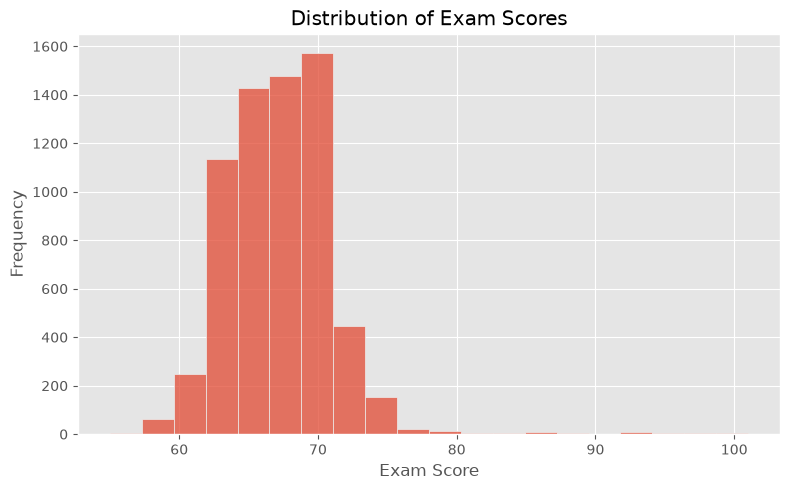

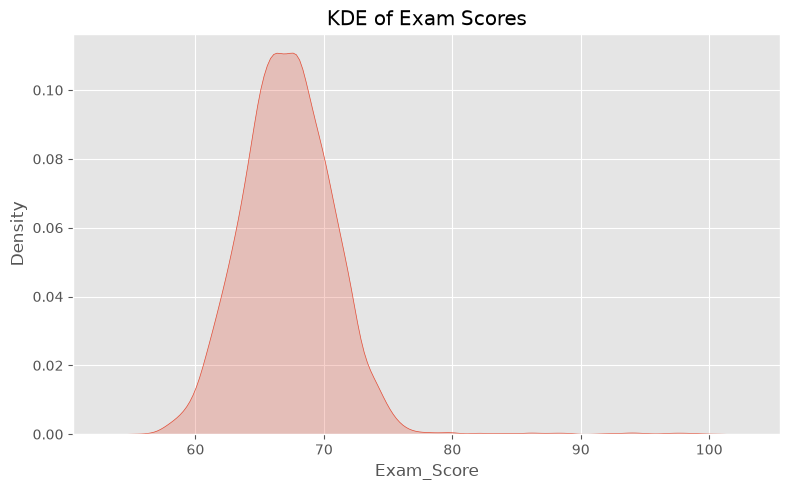

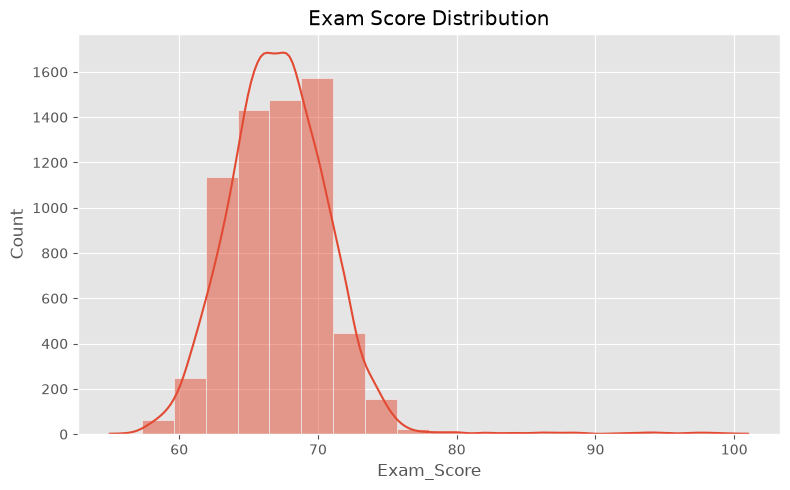

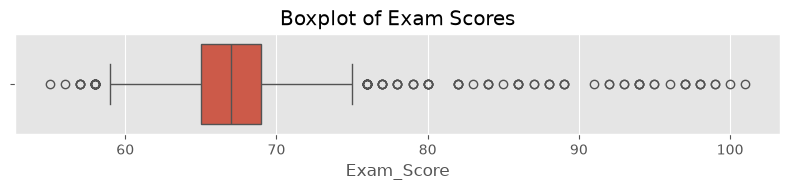

Skewness: 1.6448
Kurtosis: 10.5754


In [56]:
# save outputs

# Create output directory
OUTPUT_DIR = PROJECT_ROOT / "reports"/"figures"/"target_variable"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

#Save Summary Statistics
# Summary statistics
summary = df["Exam_Score"].describe()

print(summary)

# Save as CSV
summary.to_csv(OUTPUT_DIR / "exam_score_summary.csv")

# Save as TXT
with open(OUTPUT_DIR / "exam_score_summary.txt", "w") as file:
    file.write(str(summary))

    #Histogram
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Exam_Score",
    bins=20,
    kde=False
)

plt.title("Distribution of Exam Scores")
plt.xlabel("Exam Score")
plt.ylabel("Frequency")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "exam_score_histogram.png",
    dpi=300
)

plt.show()

# KDE Plot
plt.figure(figsize=(8,5))

sns.kdeplot(
    data=df,
    x="Exam_Score",
    fill=True
)

plt.title("KDE of Exam Scores")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "exam_score_kde.png",
    dpi=300
)

plt.show()

# Histogram + KDE
plt.figure(figsize=(8,5))

sns.histplot(
    data=df,
    x="Exam_Score",
    bins=20,
    kde=True
)

plt.title("Exam Score Distribution")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "exam_score_histogram_kde.png",
    dpi=300
)

plt.show()

# Boxplot
plt.figure(figsize=(8,2))

sns.boxplot(
    x=df["Exam_Score"]
)

plt.title("Boxplot of Exam Scores")

plt.tight_layout()

plt.savefig(
    OUTPUT_DIR / "exam_score_boxplot.png",
    dpi=300
)

plt.show()

# Skewness
skewness = df["Exam_Score"].skew()

print(f"Skewness: {skewness:.4f}")

with open(OUTPUT_DIR / "skewness.txt", "w") as file:
    file.write(f"Skewness: {skewness:.4f}")

# Kurtosis
kurtosis = df["Exam_Score"].kurtosis()

print(f"Kurtosis: {kurtosis:.4f}")

with open(OUTPUT_DIR / "kurtosis.txt", "w") as file:
    file.write(f"Kurtosis: {kurtosis:.4f}")

# =====================================================
# Numerical Feature Analysis
# =====================================================

## Identify Numerical Columns

In [57]:
# Select numerical columns
numerical_columns = df.select_dtypes(include=["int64", "float64"]).columns

print("Numerical Features:")
print(numerical_columns)

Numerical Features:
Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='str')


In [58]:
# Generate Summary Statistics
summary = df[numerical_columns].agg(
    ["mean", "median", "std", "min", "max"]
).T

summary

,mean,median,std,min,max
Hours_Studied,19.975329,20.0,5.990594,1.0,44.0
Attendance,79.977448,80.0,11.547475,60.0,100.0
Sleep_Hours,7.029060,7.0,1.468120,4.0,10.0
Previous_Scores,75.070531,75.0,14.399784,50.0,100.0
Tutoring_Sessions,1.493719,1.0,1.230570,0.0,8.0
Physical_Activity,2.967610,3.0,1.031231,0.0,6.0
Exam_Score,67.235659,67.0,3.890456,55.0,101.0


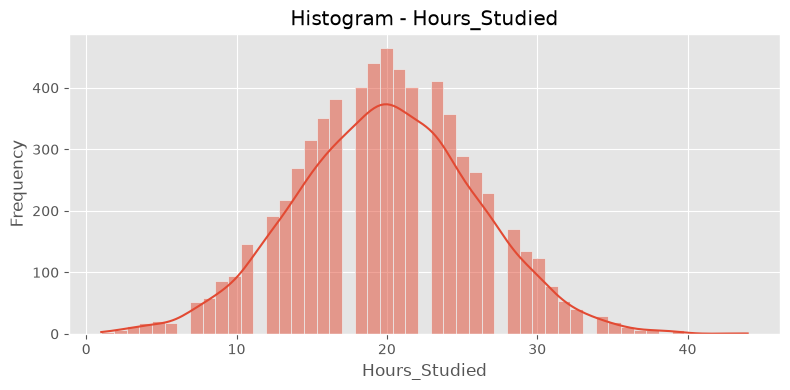

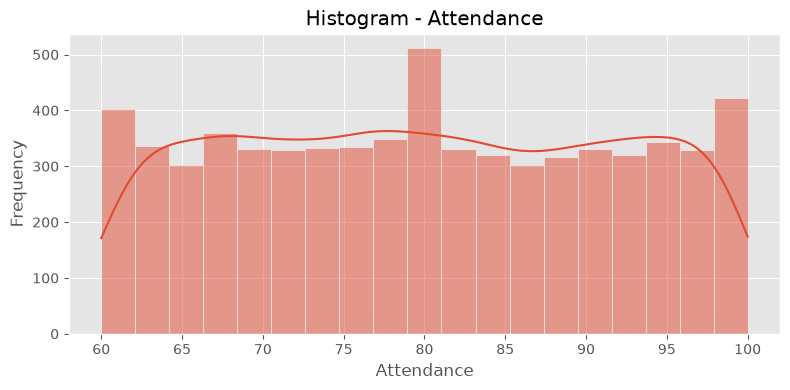

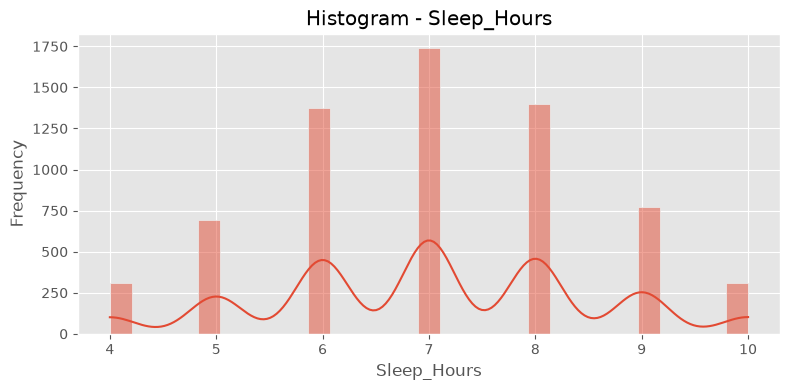

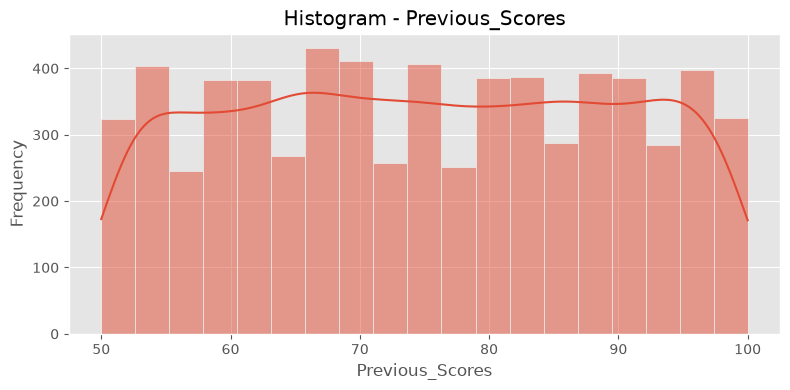

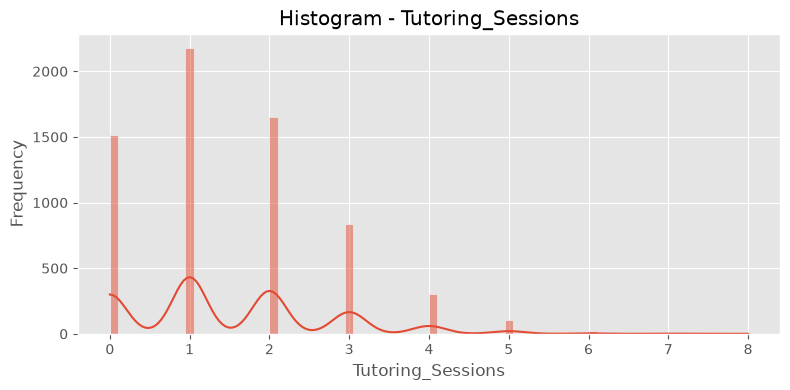

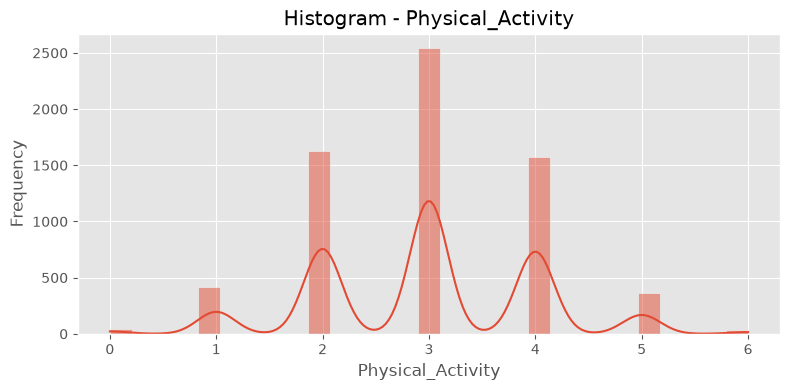

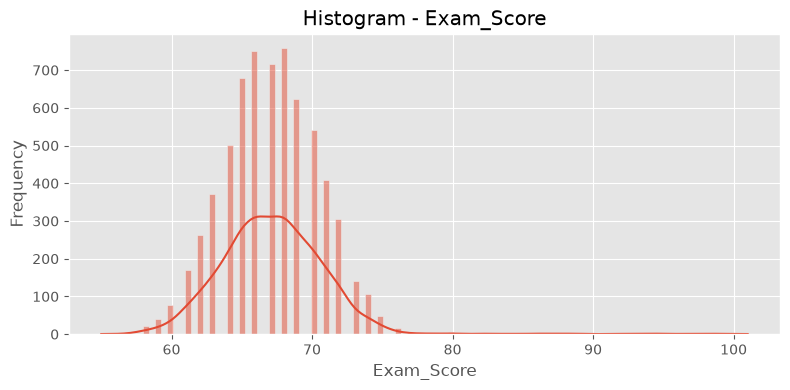

In [67]:
# Histogram for Every Numerical Feature
for column in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.histplot(df[column], kde=True)

    plt.title(f"Histogram - {column}")

    plt.xlabel(column)

    plt.ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(
    f"../reports/figures/Numerical_Feature_Analysis/histogram_{column}.png",
    dpi=300,
    bbox_inches="tight"
)

    plt.show()

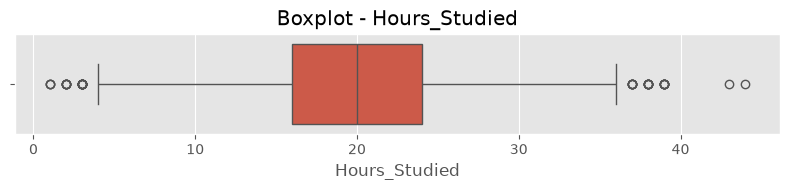

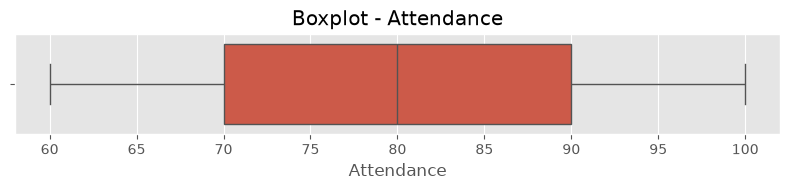

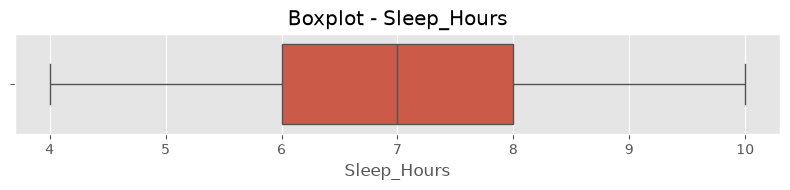

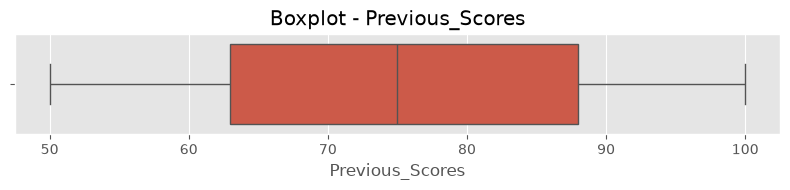

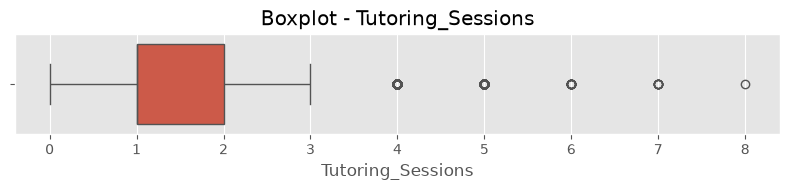

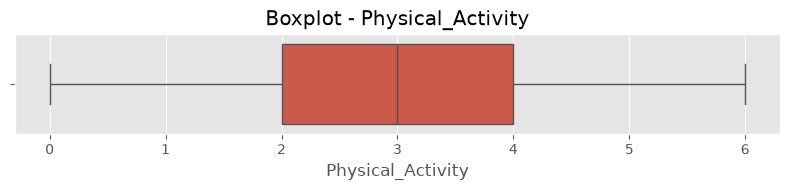

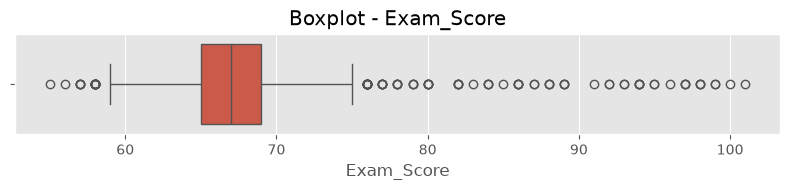

In [69]:
# Boxplot for Every Numerical Feature
for column in numerical_columns:

    plt.figure(figsize=(8,2))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot - {column}")

    plt.tight_layout()

    plt.savefig(
    f"../reports/figures/Numerical_Feature_Analysis/boxplot_{column}.png",
    dpi=300,
    bbox_inches="tight"
)


    plt.show()

In [62]:
# Save Summary
summary.to_csv(
    "../reports/metrics/numerical_summary.csv"
)

summary

,mean,median,std,min,max
Hours_Studied,19.975329,20.0,5.990594,1.0,44.0
Attendance,79.977448,80.0,11.547475,60.0,100.0
Sleep_Hours,7.029060,7.0,1.468120,4.0,10.0
Previous_Scores,75.070531,75.0,14.399784,50.0,100.0
Tutoring_Sessions,1.493719,1.0,1.230570,0.0,8.0
Physical_Activity,2.967610,3.0,1.031231,0.0,6.0
Exam_Score,67.235659,67.0,3.890456,55.0,101.0


# =====================================================
# Categorical Feature Analysis
# =====================================================

In [70]:
# Theory

# Categorical features usually have the data type:

# object
# category

# We first identify them instead of hardcoding column names.


# Select categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("Categorical Columns:")
print(categorical_columns.tolist())

Categorical Columns:
['Parental_Involvement', 'Access_to_Resources', 'Extracurricular_Activities', 'Motivation_Level', 'Internet_Access', 'Family_Income', 'Teacher_Quality', 'School_Type', 'Peer_Influence', 'Learning_Disabilities', 'Parental_Education_Level', 'Distance_from_Home', 'Gender']


In [71]:
# Count the Categories
# 💡 Theory

# We want to know:

# How many students belong to each category?
# Are some categories very rare?

for column in categorical_columns:
    print("=" * 50)
    print(f"Column: {column}")
    print(df[column].value_counts())
    print()

Column: Parental_Involvement
Parental_Involvement
Medium    3362
High      1908
Low       1337
Name: count, dtype: int64

Column: Access_to_Resources
Access_to_Resources
Medium    3319
High      1975
Low       1313
Name: count, dtype: int64

Column: Extracurricular_Activities
Extracurricular_Activities
Yes    3938
No     2669
Name: count, dtype: int64

Column: Motivation_Level
Motivation_Level
Medium    3351
Low       1937
High      1319
Name: count, dtype: int64

Column: Internet_Access
Internet_Access
Yes    6108
No      499
Name: count, dtype: int64

Column: Family_Income
Family_Income
Low       2672
Medium    2666
High      1269
Name: count, dtype: int64

Column: Teacher_Quality
Teacher_Quality
Medium    3925
High      1947
Low        657
Name: count, dtype: int64

Column: School_Type
School_Type
Public     4598
Private    2009
Name: count, dtype: int64

Column: Peer_Influence
Peer_Influence
Positive    2638
Neutral     2592
Negative    1377
Name: count, dtype: int64

Column: Learn

In [72]:
# Category Percentages
# 💡 Theory

# Raw counts don't always tell the full story. Percentages help compare distributions.


for column in categorical_columns:
    print("=" * 50)
    print(f"{column} (%)")
    print(df[column].value_counts(normalize=True) * 100)
    print()

Parental_Involvement (%)
Parental_Involvement
Medium    50.885425
High      28.878462
Low       20.236113
Name: proportion, dtype: float64

Access_to_Resources (%)
Access_to_Resources
Medium    50.234600
High      29.892538
Low       19.872862
Name: proportion, dtype: float64

Extracurricular_Activities (%)
Extracurricular_Activities
Yes    59.603451
No     40.396549
Name: proportion, dtype: float64

Motivation_Level (%)
Motivation_Level
Medium    50.718934
Low       29.317391
High      19.963675
Name: proportion, dtype: float64

Internet_Access (%)
Internet_Access
Yes    92.447404
No      7.552596
Name: proportion, dtype: float64

Family_Income (%)
Family_Income
Low       40.441956
Medium    40.351143
High      19.206902
Name: proportion, dtype: float64

Teacher_Quality (%)
Teacher_Quality
Medium    60.116404
High      29.820800
Low       10.062797
Name: proportion, dtype: float64

School_Type (%)
School_Type
Public     69.592856
Private    30.407144
Name: proportion, dtype: float64



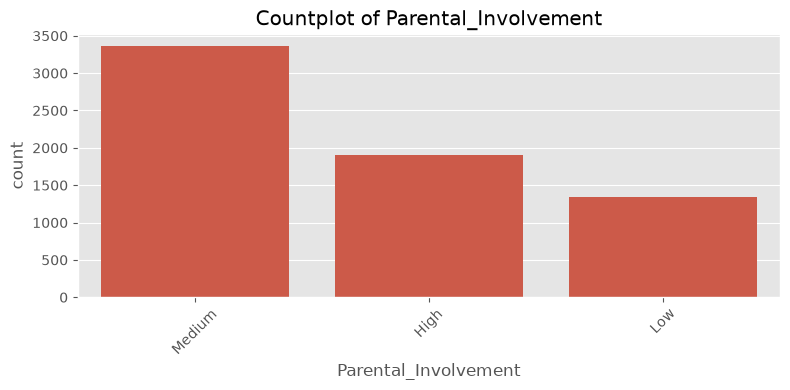

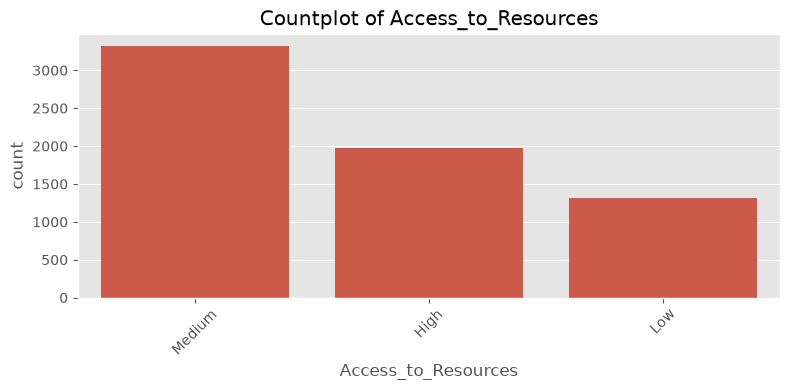

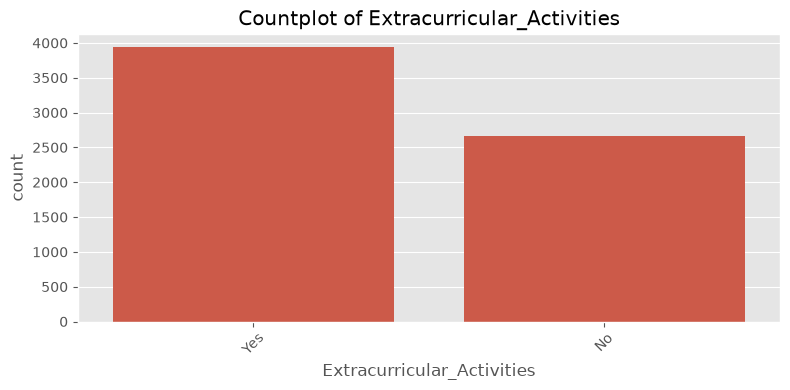

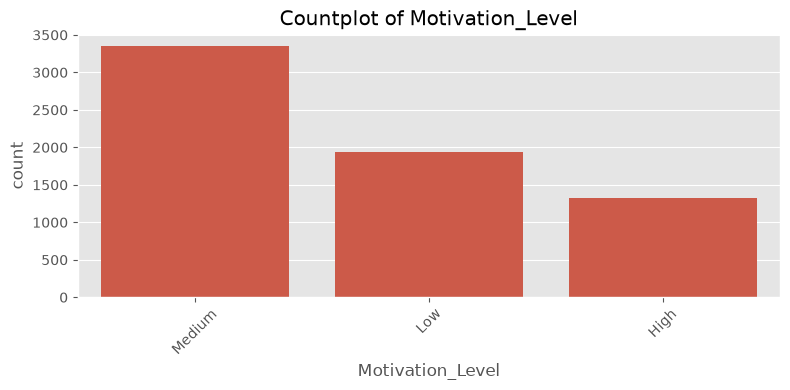

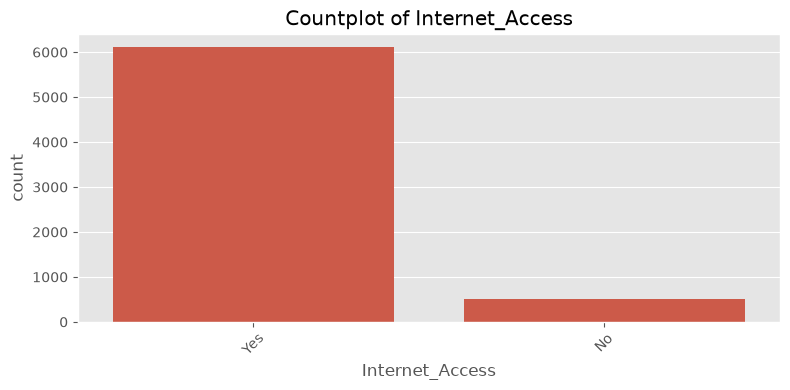

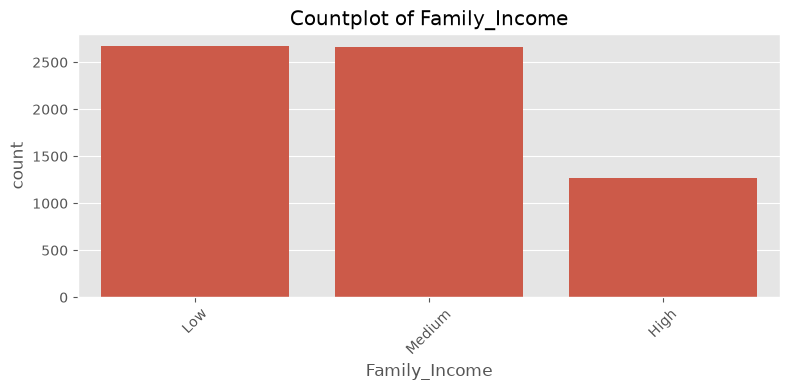

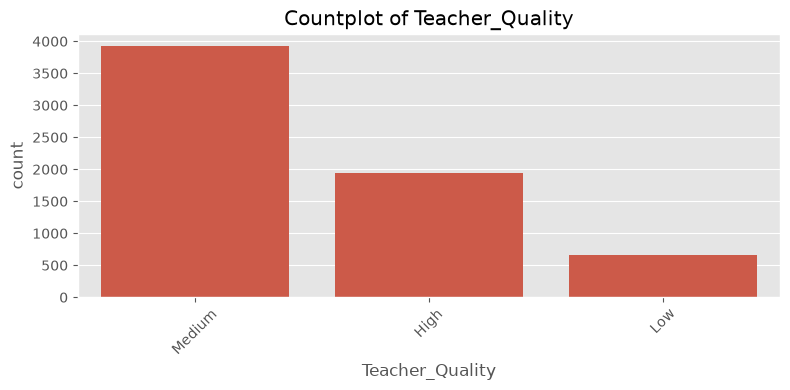

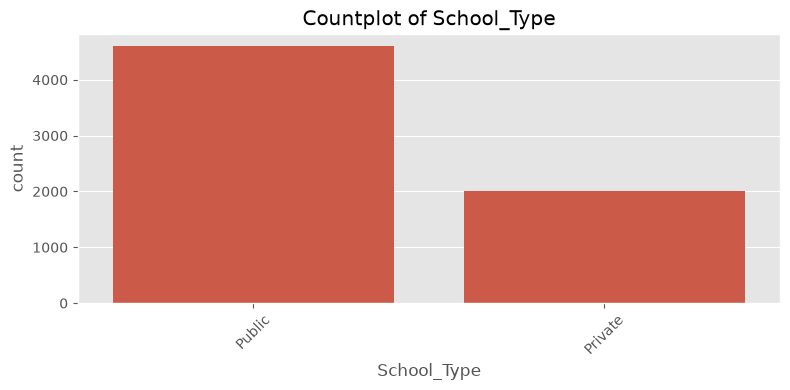

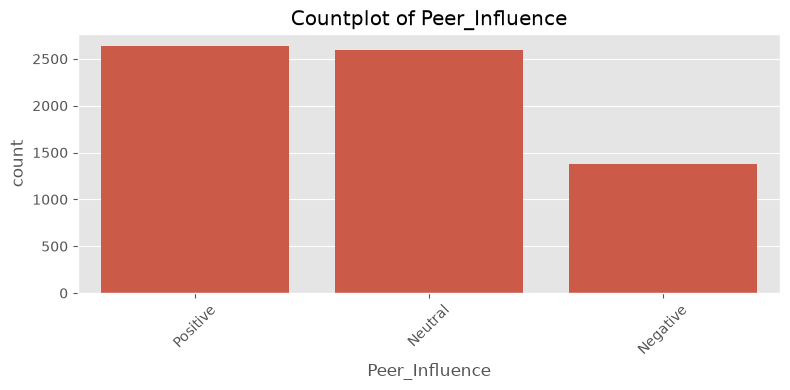

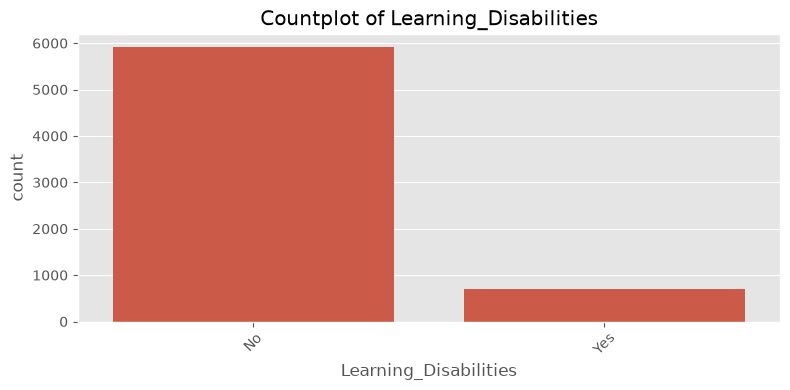

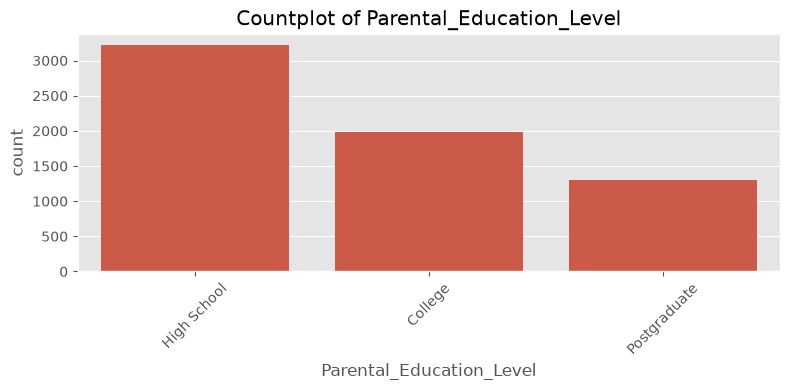

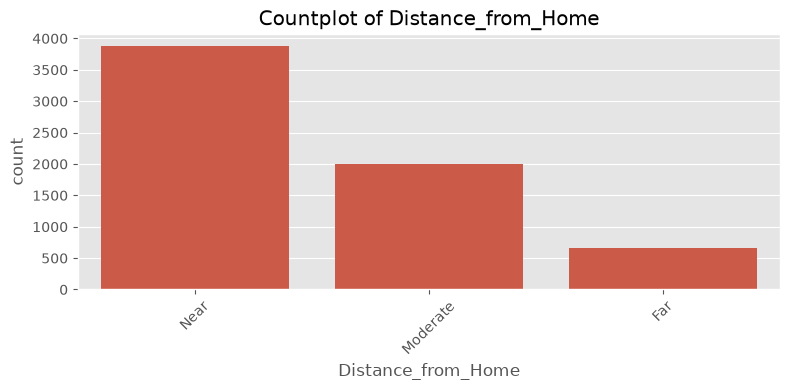

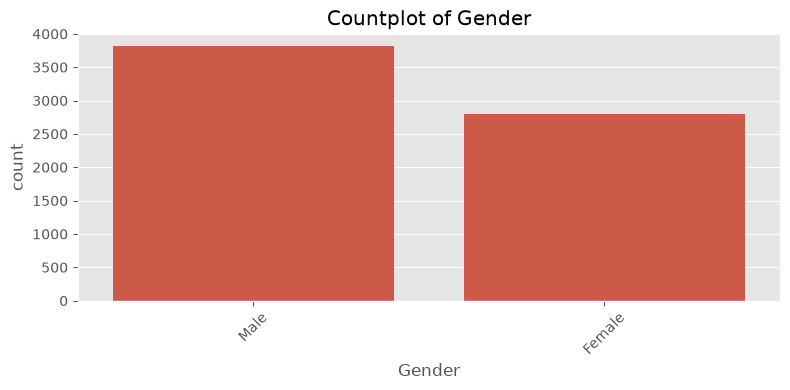

In [76]:
# Countplot
# 💡 Theory

# A countplot shows the number of records in each category.

# It's one of the most common visualizations for categorical data.


import matplotlib.pyplot as plt
import seaborn as sns

for column in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"Countplot of {column}")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.show()

In [77]:
# Save the Charts

# Instead of only displaying them, save them for your report.

import os

os.makedirs("reports/figures", exist_ok=True)

for column in categorical_columns:

    plt.figure(figsize=(8,4))

    sns.countplot(
        data=df,
        x=column,
        order=df[column].value_counts().index
    )

    plt.title(f"{column}")

    plt.xticks(rotation=45)

    plt.tight_layout()

    plt.savefig(f"../reports/figures/Categorical Feature Analysis/{column}_countplot.png")

    plt.close()

In [79]:
# Summary Table

# Instead of manually writing observations, create a summary DataFrame.

summary = pd.DataFrame({

    "Feature": categorical_columns,

    "Unique Values": [
        df[col].nunique()
        for col in categorical_columns
    ],

    "Missing Values": [
        df[col].isnull().sum()
        for col in categorical_columns
    ],

    "Most Common Category": [
        df[col].mode()[0]
        for col in categorical_columns
    ],

    "Frequency": [
        df[col].value_counts().iloc[0]
        for col in categorical_columns
    ]

})

summary

,Feature,Unique Values,Missing Values,Most Common Category,Frequency
0,Parental_Involvement,3,0,Medium,3362
1,Access_to_Resources,3,0,Medium,3319
2,Extracurricular_Activities,2,0,Yes,3938
3,Motivation_Level,3,0,Medium,3351
4,Internet_Access,2,0,Yes,6108
5,Family_Income,3,0,Low,2672
6,Teacher_Quality,3,78,Medium,3925
7,School_Type,2,0,Public,4598
8,Peer_Influence,3,0,Positive,2638
9,Learning_Disabilities,2,0,No,5912


# =====================================================
# Categorical Feature Analysis
# =====================================================

#### Objective

Analyze the relationship between numerical variables to identify:

Strong positive correlations
Strong negative correlations
Weak relationships
Potential multicollinearity
Features most related to the target variable (Exam_Score)

#### Theory

Correlation measures the strength and direction of the relationship between two numerical variables.

Correlation values range from -1 to +1.

Correlation	Meaning
+1	Perfect positive correlation
+0.7 to +1.0	Strong positive relationship
+0.3 to +0.7	Moderate positive relationship
0	No relationship
-0.3 to -0.7	Moderate negative relationship
-0.7 to -1.0	Strong negative relationship
-1	Perfect negative correlation

In [80]:
# Calculate correlation matrix for numerical features
corr = df.corr(numeric_only=True)

# Display correlation matrix
corr

,Hours_Studied,Attendance,Sleep_Hours,Previous_Scores,Tutoring_Sessions,Physical_Activity,Exam_Score
Hours_Studied,1.000000,-0.009908,0.010977,0.024846,-0.014282,0.004624,0.445455
Attendance,-0.009908,1.000000,-0.015918,-0.020186,0.014324,-0.022435,0.581072
Sleep_Hours,0.010977,-0.015918,1.000000,-0.021750,-0.012216,-0.000378,-0.017022
Previous_Scores,0.024846,-0.020186,-0.021750,1.000000,-0.013122,-0.011274,0.175079
Tutoring_Sessions,-0.014282,0.014324,-0.012216,-0.013122,1.000000,0.017733,0.156525
Physical_Activity,0.004624,-0.022435,-0.000378,-0.011274,0.017733,1.000000,0.027824
Exam_Score,0.445455,0.581072,-0.017022,0.175079,0.156525,0.027824,1.000000


In [ ]:
# Create Heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.show()

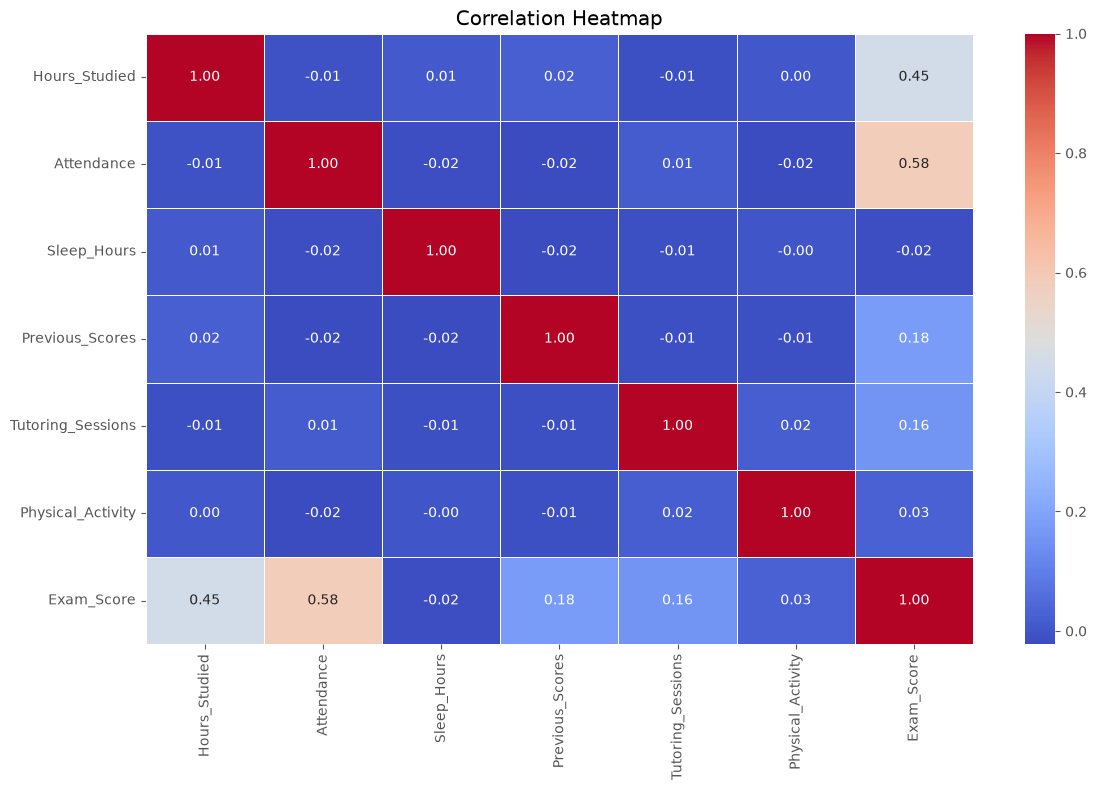

In [ ]:
# Save Heatmap
import os

# Create folder if it doesn't exist
os.makedirs("reports/figures", exist_ok=True)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.tight_layout()

plt.savefig(
    "../reports/figures/Correlation/correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [82]:
# Correlation with Target Variable

# This is actually more useful than the full heatmap.

# Correlation with target variable
target_corr = corr["Exam_Score"].sort_values(ascending=False)

target_corr

Exam_Score           1.000000
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022
Name: Exam_Score, dtype: float64

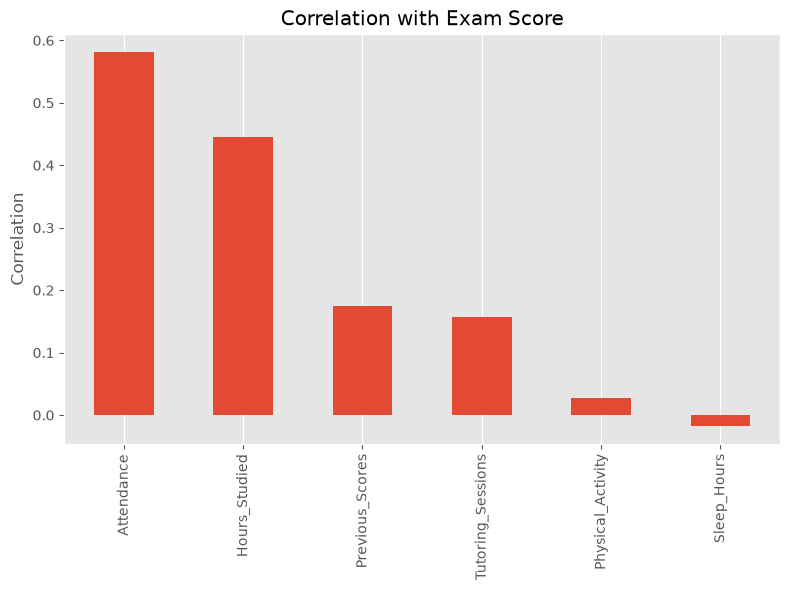

In [ ]:
# Visualize Target Correlation
plt.figure(figsize=(8,6))

target_corr.drop("Exam_Score").plot(kind="bar")

plt.title("Correlation with Exam Score")

plt.ylabel("Correlation")

plt.grid(axis="y")

plt.tight_layout()

plt.savefig(
    "../reports/figures/Correlation/Visualize Target Correlation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# ============================
# Outlier Detection
# ============================

Objective

Identify unusual or extreme values (outliers) in the dataset that could negatively affect model performance.

Theory
What is an Outlier?

An outlier is a data point that is significantly different from the rest of the observations.

Example:

Hours Studied
2
3
4
5
4
3
100

Here, 100 is clearly an outlier.

Outliers can occur because of:

Data entry mistakes
Measurement errors
Genuine but rare observations
Why Detect Outliers?

Outliers can:

Reduce model accuracy
Mislead statistical analysis
Distort the mean and standard deviation
Cause regression models to fit poorly

However, not every outlier should be removed. Sometimes it represents a real and important observation.

Why Use a Boxplot?

A boxplot visually summarizes:

Minimum value
First Quartile (Q1)
Median (Q2)
Third Quartile (Q3)
Maximum value
Potential outliers
      ○   ← Outlier

      |
  ───────────
 |          |
 |   Box    |
 |          |
  ───────────
     |

Points outside the whiskers are considered potential outliers.

In [85]:
# Select Numerical Columns
import numpy as np

numerical_columns = df.select_dtypes(include=np.number).columns

print(numerical_columns)

Index(['Hours_Studied', 'Attendance', 'Sleep_Hours', 'Previous_Scores',
       'Tutoring_Sessions', 'Physical_Activity', 'Exam_Score'],
      dtype='str')


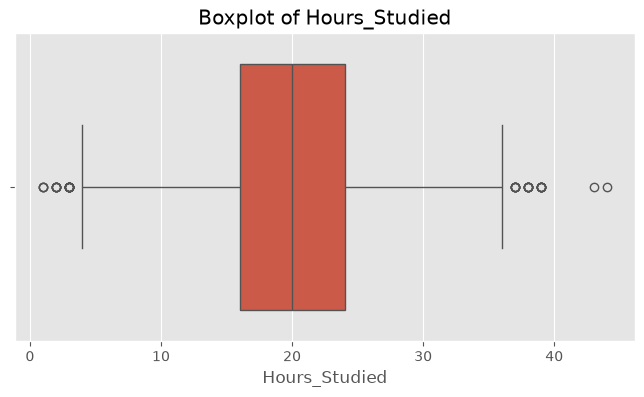

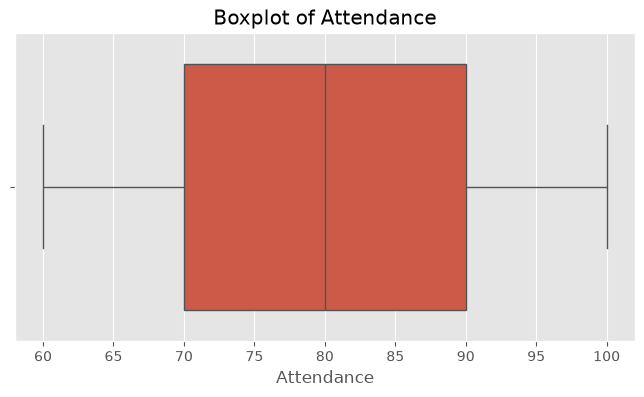

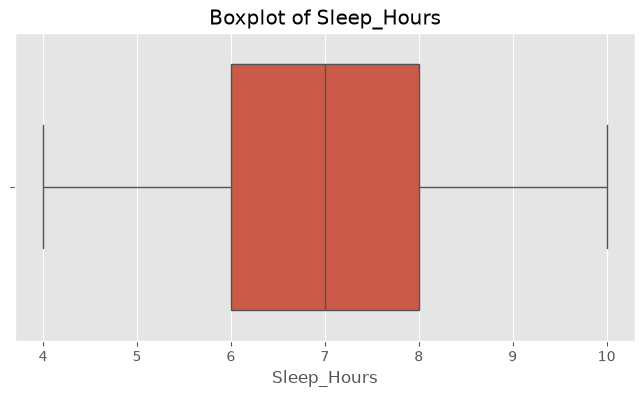

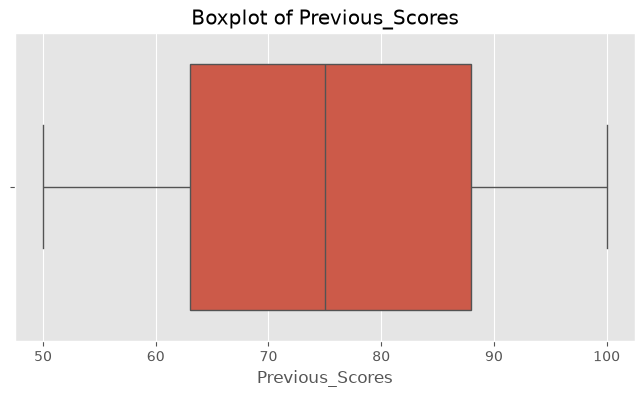

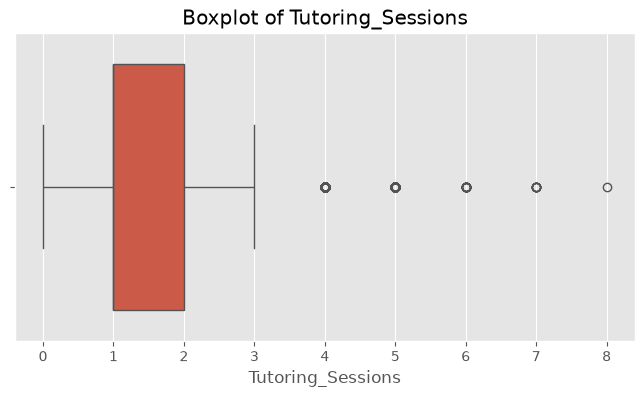

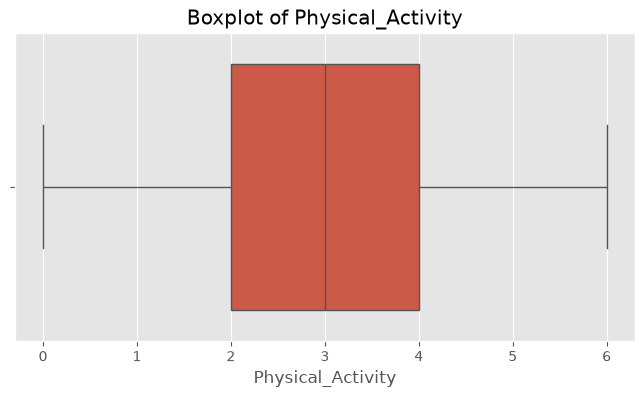

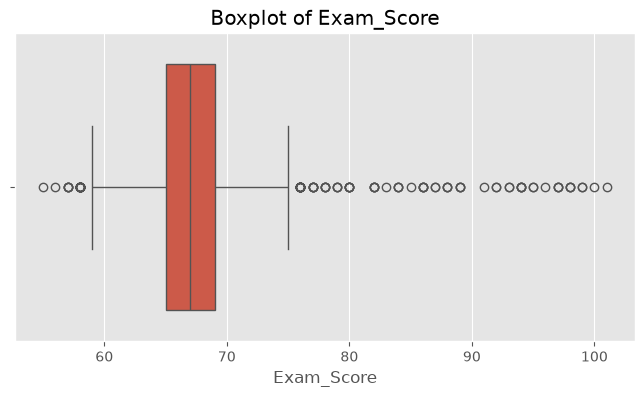

In [86]:
# Create Boxplots for Every Numerical Feature
import matplotlib.pyplot as plt
import seaborn as sns

for column in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.xlabel(column)

    plt.show()

In [87]:
# Identify Outliers Using the IQR Method

# The Interquartile Range (IQR) method is one of the most common techniques.

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[
        (df[column] < lower) |
        (df[column] > upper)
    ]

    print(f"{column}")
    print(f"Number of Outliers: {len(outliers)}")
    print("-" * 40)

Hours_Studied
Number of Outliers: 43
----------------------------------------
Attendance
Number of Outliers: 0
----------------------------------------
Sleep_Hours
Number of Outliers: 0
----------------------------------------
Previous_Scores
Number of Outliers: 0
----------------------------------------
Tutoring_Sessions
Number of Outliers: 430
----------------------------------------
Physical_Activity
Number of Outliers: 0
----------------------------------------
Exam_Score
Number of Outliers: 104
----------------------------------------


In [88]:
import os

os.makedirs("reports/figures", exist_ok=True)

for column in numerical_columns:

    plt.figure(figsize=(8,4))

    sns.boxplot(x=df[column])

    plt.title(f"Boxplot of {column}")

    plt.savefig(
        f"../reports/figures/Outlier Analysis/{column}_boxplot.png",
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()

# ============================
# Feature Relationships
# ============================

## Objective

Understand whether a feature has a relationship with the target variable and whether that relationship is positive, negative, linear, or weak.

Theory

A feature relationship analysis helps answer questions like:

Does studying more hours lead to higher exam scores?
Does attendance affect exam performance?
Are previous scores a good predictor?
Which features appear to have the strongest influence?

We use:

Scatter Plot → Shows the relationship between two numeric variables.
Regression Plot → Shows the scatter plus the fitted regression line.

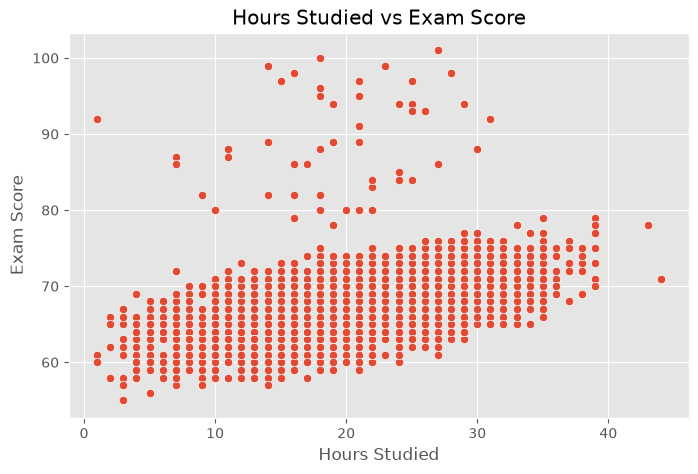

In [98]:
# Hours Studied vs Exam Score

plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score"
)

plt.title("Hours Studied vs Exam Score")
plt.xlabel("Hours Studied")
plt.ylabel("Exam Score")

plt.savefig(
    "../reports/figures/Feature Relationships/hours_studied_vs_exam_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

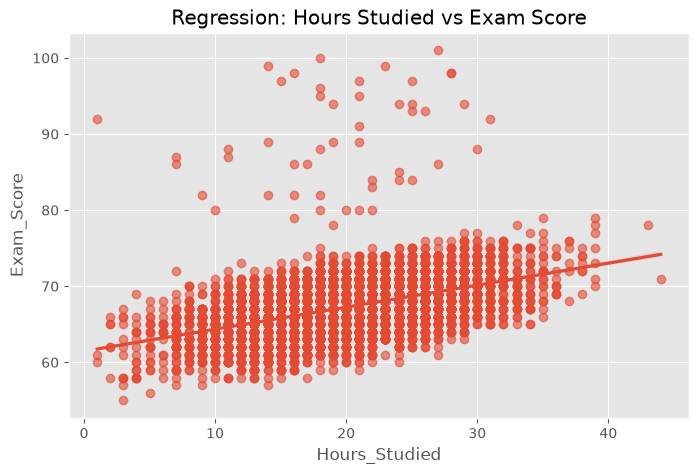

In [100]:
# Regression Plot

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Hours_Studied",
    y="Exam_Score",
    scatter_kws={"alpha":0.6}
)

plt.title("Regression: Hours Studied vs Exam Score")

plt.savefig(
    "../reports/figures/Feature Relationships/Regression:hours_studied_vs_exam_score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

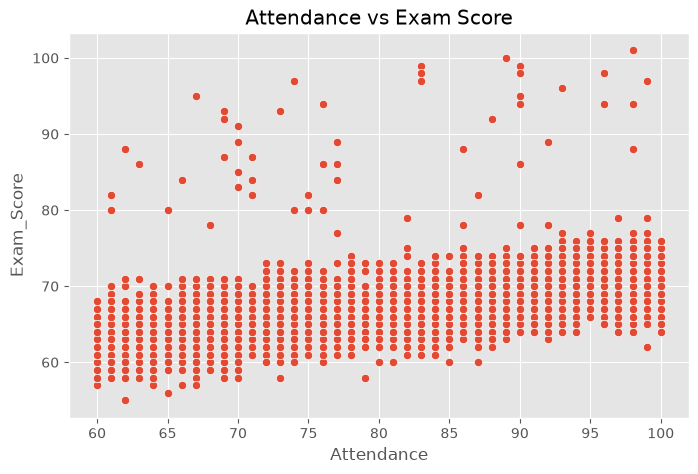

In [101]:
# 02 - Attendance vs Exam Score
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Attendance",
    y="Exam_Score"
)

plt.title("Attendance vs Exam Score")

plt.savefig(
    "../reports/figures/Feature Relationships/Attendance vs Exam Score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

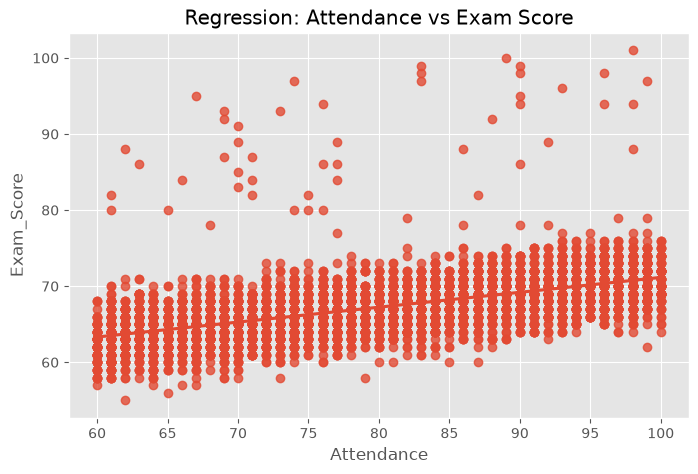

In [ ]:
# Regression:

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Attendance",
    y="Exam_Score"
)

plt.title("Regression: Attendance vs Exam Score")

plt.show()

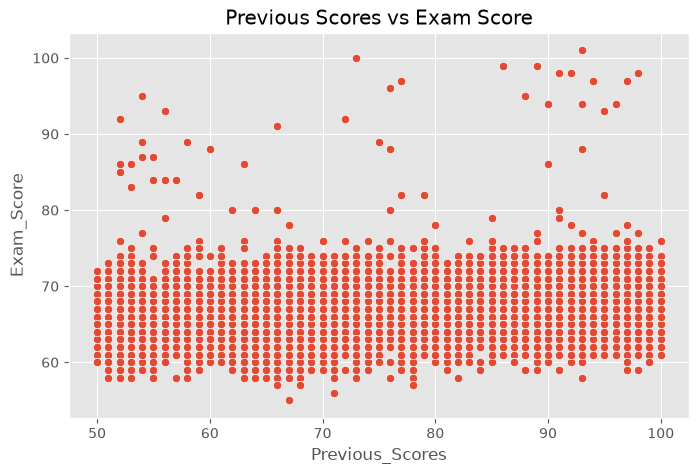

In [104]:
# 3 — Previous Scores vs Exam Score
plt.figure(figsize=(8,5))

sns.scatterplot(
    data=df,
    x="Previous_Scores",
    y="Exam_Score"
)

plt.title("Previous Scores vs Exam Score")

plt.savefig(
    "../reports/figures/Feature Relationships/Previous Scores vs Exam Score.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

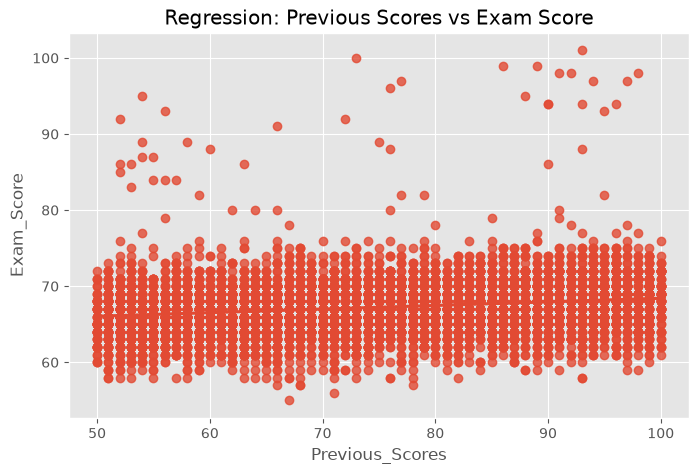

In [96]:
# Regression:

plt.figure(figsize=(8,5))

sns.regplot(
    data=df,
    x="Previous_Scores",
    y="Exam_Score"
)

plt.title("Regression: Previous Scores vs Exam Score")

plt.show()

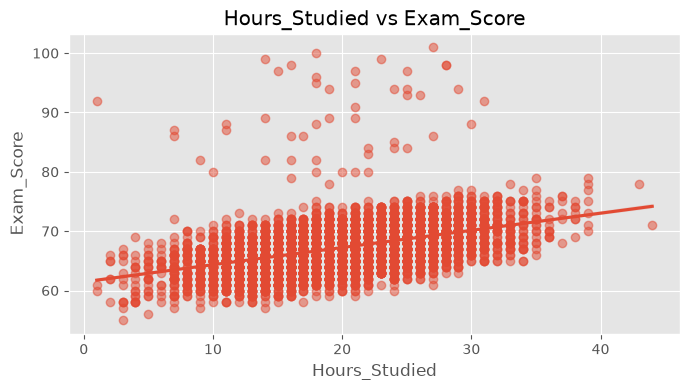

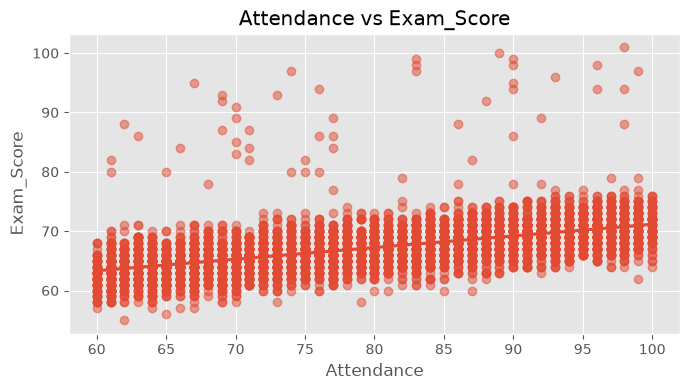

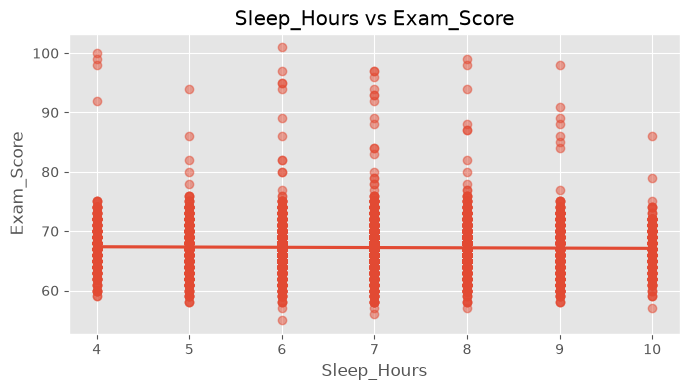

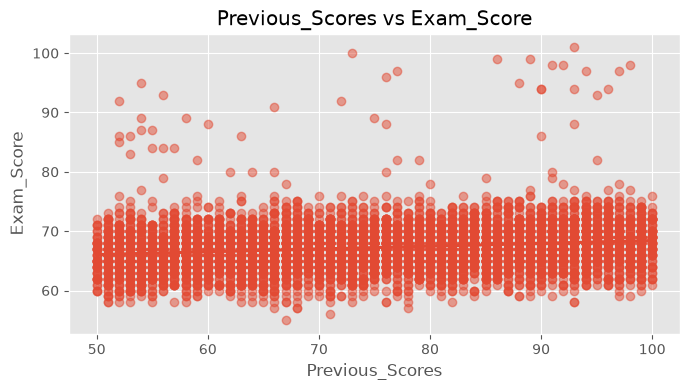

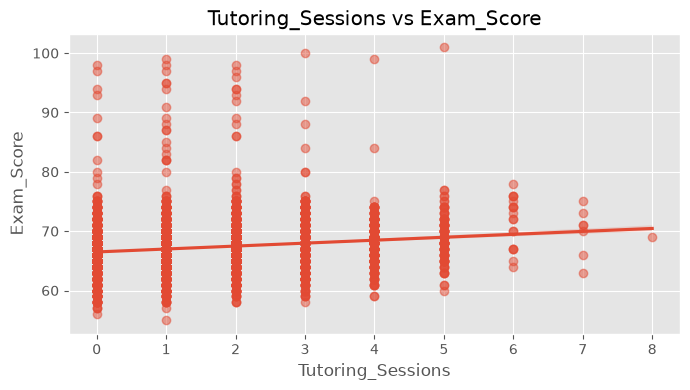

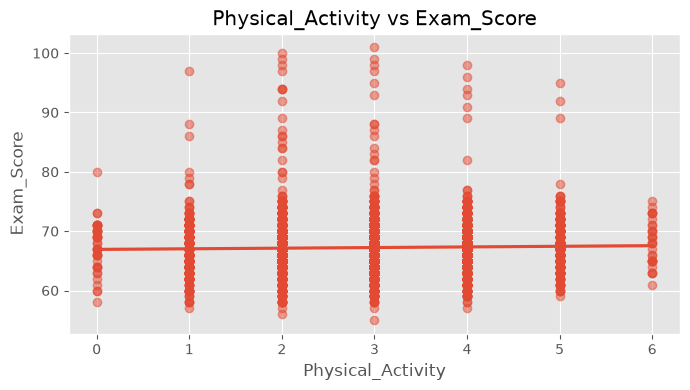

In [105]:
# Analyze All Numerical Features Automatically

# Instead of writing separate code for every numeric feature, use a loop.

import numpy as np

target = "Exam_Score"

numerical_columns = df.select_dtypes(include=np.number).columns.tolist()

numerical_columns.remove(target)

for column in numerical_columns:

    plt.figure(figsize=(7,4))

    sns.regplot(
        data=df,
        x=column,
        y=target,
        scatter_kws={"alpha":0.5}
    )

    plt.title(f"{column} vs {target}")

    plt.tight_layout()

    plt.show()